🚨 [Timestep 35] Inverse jump caught! A: 25.00, B: -5.00


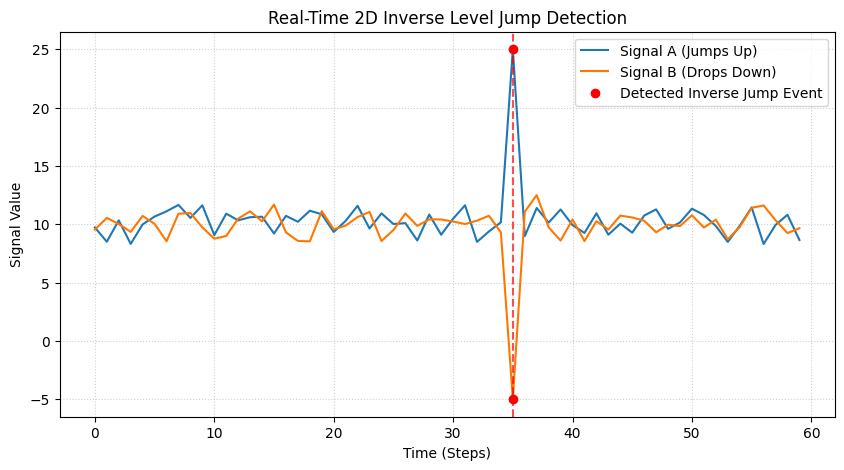

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class OnlineInverseJumpDetector2D:
    def __init__(self, threshold_chi2=12.0, warmup_period=20):
        self.threshold = threshold_chi2
        self.warmup = warmup_period
        self.count = 0
        self.mean = np.zeros(2)
        self.S = np.zeros((2, 2))

    def process_point(self, x):
        x = np.asarray(x, dtype=float)
        self.count += 1

        # Warmup Phase
        if self.count <= self.warmup:
            old_delta = x - self.mean
            self.mean += old_delta / self.count
            new_delta = x - self.mean
            self.S += np.outer(old_delta, new_delta)
            return "WARMUP"

        # Calculate Running Covariance
        covariance = self.S / (self.count - 1)
        covariance += np.eye(2) * 1e-6  # Regularization

        # Calculate Mahalanobis Distance
        delta = x - self.mean
        try:
            inv_covariance = np.linalg.inv(covariance)
            mahalanobis_dist = np.dot(delta.T, np.dot(inv_covariance, delta))
        except np.linalg.LinAlgError:
            mahalanobis_dist = 0.0

        # Check for inverse divergence (signs of deviations are opposite)
        is_anomalous_distance = mahalanobis_dist > self.threshold
        diverging_directions = np.sign(delta[0]) != np.sign(delta[1])
        
        if is_anomalous_distance and diverging_directions:
            return "INVERSE_JUMP"
        else:
            # Update baseline for normal points
            old_delta = x - self.mean
            self.mean += old_delta / self.count
            new_delta = x - self.mean
            self.S += np.outer(old_delta, new_delta)
            return "NORMAL"

# --- Live Streaming Simulation and Plotting ---
np.random.seed(42)
total_points = 60
# Generate normal noisy data centered around baseline (10, 10)
stream_data = np.random.multivariate_normal(mean=[10, 10], cov=[[1, 0.1], [0.1, 1]], size=total_points)

# Inject an intentional abrupt inverse level jump at timestep 35
# Signal A jumps UP (+15) and Signal B drops DOWN (-15)
stream_data[35] = np.array([25.0, -5.0])

detector = OnlineInverseJumpDetector2D()
results = []
anomalies_x = []
anomalies_y_a = []
anomalies_y_b = []

# Process the data point-by-point
for t, point in enumerate(stream_data):
    status = detector.process_point(point)
    results.append(status)
    if status == "INVERSE_JUMP":
        anomalies_x.append(t)
        anomalies_y_a.append(point[0])
        anomalies_y_b.append(point[1])
        print(f"🚨 [Timestep {t}] Inverse jump caught! A: {point[0]:.2f}, B: {point[1]:.2f}")

# Generate the plot
plt.figure(figsize=(10, 5))
plt.plot(stream_data[:, 0], label="Signal A (Jumps Up)", color="#1f77b4", linewidth=1.5)
plt.plot(stream_data[:, 1], label="Signal B (Drops Down)", color="#ff7700", linewidth=1.5)

# Highlight detected inverse jumps with red vertical dashed lines and dots
if anomalies_x:
    plt.scatter(anomalies_x, anomalies_y_a, color="red", zorder=5, label="Detected Inverse Jump Event")
    plt.scatter(anomalies_x, anomalies_y_b, color="red", zorder=5)
    for cx in anomalies_x:
        plt.axvline(x=cx, color="red", linestyle="--", alpha=0.7)

plt.title("Real-Time 2D Inverse Level Jump Detection")
plt.xlabel("Time (Steps)")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()